# <center style = 'color : white'> Wine Quality </center>

# <center>**Data preprocessing**</center>

# 1. Data Loading and Initial Inspection

In this section we:
- Import the main libraries
- Load the `wine.csv` dataset
- Get a first overview of the data structure



In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
# 1.1 Load the dataset
db = pd.read_csv("wine.csv")

In [79]:
# 1.2 Basic preview
print("Shape of dataset:", db.shape)
display(db.head())      # first rows
display(db.tail())      # last rows

Shape of dataset: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [80]:
# 1.3 Data types and non-null counts
print("db.info()")
db.info()

db.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [81]:
# 1.4 Basic statistics (numeric columns)
print("db.describe()")
display(db.describe().T)

db.describe()


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [82]:
# 1.5 Check for missing values
print("Missing values per colum")
display(db.isnull().sum())

Missing values per colum


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


# 2. Basic Data Quality Checks

In this section we:
- Verify whether there are duplicated rows in the dataset and remove them if needed.
- Explicitly define the **target variable** (`quality`) and the **feature variables** (all other columns).
- Confirm that all features are numeric and ready for further analysis.

In [83]:
# 2.1 Check for duplicated rows
num_duplicates = db.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 240


In [84]:
if num_duplicates > 0:
    db = db.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", db.shape)

Duplicates removed. New shape: (1359, 12)


In [85]:
num_duplicates = db.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 0


In [86]:
# 2.2 Identify target and feature columns
target_col = "quality"   # this is our output variable
feature_cols = [col for col in db.columns if col != target_col]

print("\nTarget column:", target_col)
print("Feature columns:", feature_cols)


Target column: quality
Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


# 3. Visualization – Target Variable (Wine Quality)

In this section we:
- Analyze the distribution of the target variable `quality`, which represents the wine's quality score (from 3 to 8).
- Display the number of samples for each quality level using `value_counts()` to understand class frequencies.
- Create a bar chart to visualize class balance.
- Identify whether the dataset is balanced or imbalanced, which is important for selecting appropriate evaluation metrics in modeling.


## 3.1 Target Variable (Wine Quality)


Value counts for wine quality (sorted):
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


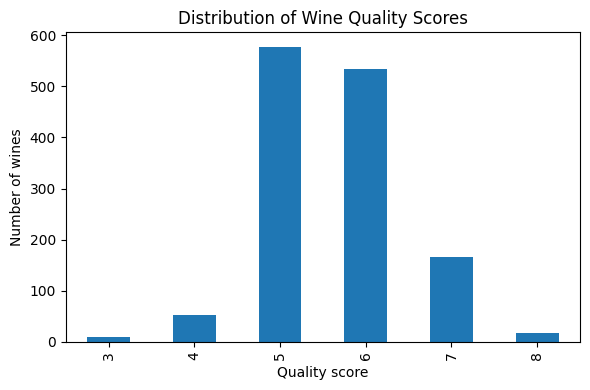

In [87]:
print("Value counts for wine quality (sorted):")
print(db["quality"].value_counts().sort_index())

plt.figure(figsize=(6, 4))
db["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality score")
plt.ylabel("Number of wines")
plt.tight_layout()
plt.show()

## 3.2 Visualization – Distributions of Physicochemical Features

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


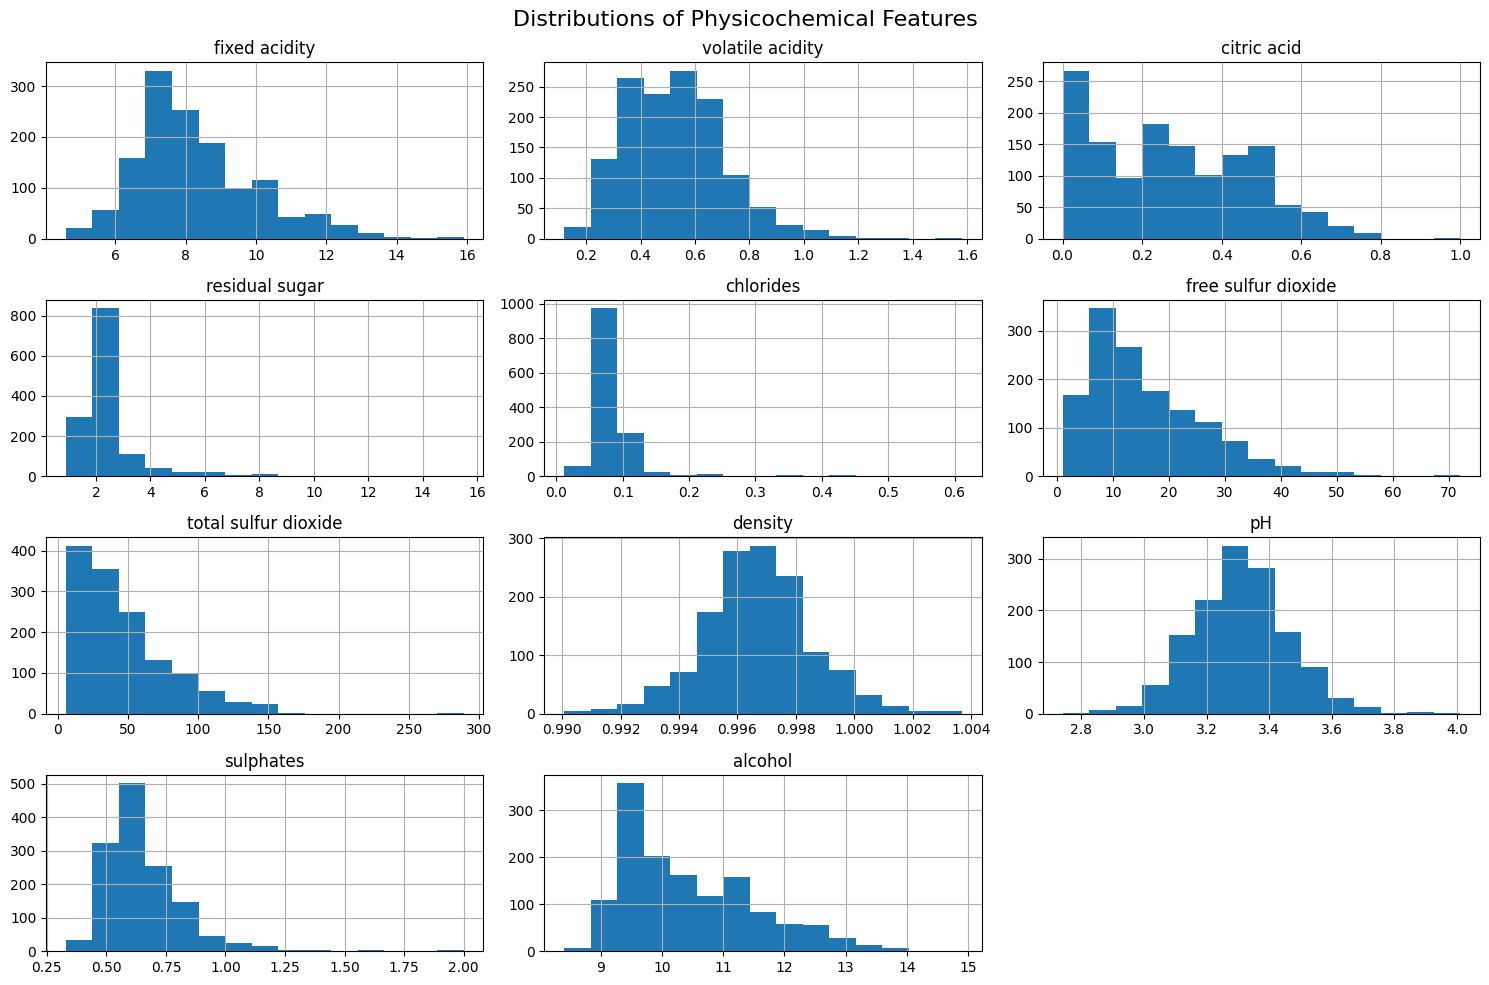

In [88]:
display(db[feature_cols].describe().T)  # table, not a plot but useful

db[feature_cols].hist(bins=15, figsize=(15, 10))
plt.suptitle("Distributions of Physicochemical Features", fontsize=16)
plt.tight_layout()
plt.show()

## 3.3 Visualization – Relationship Between Features and Quality (Boxplots)

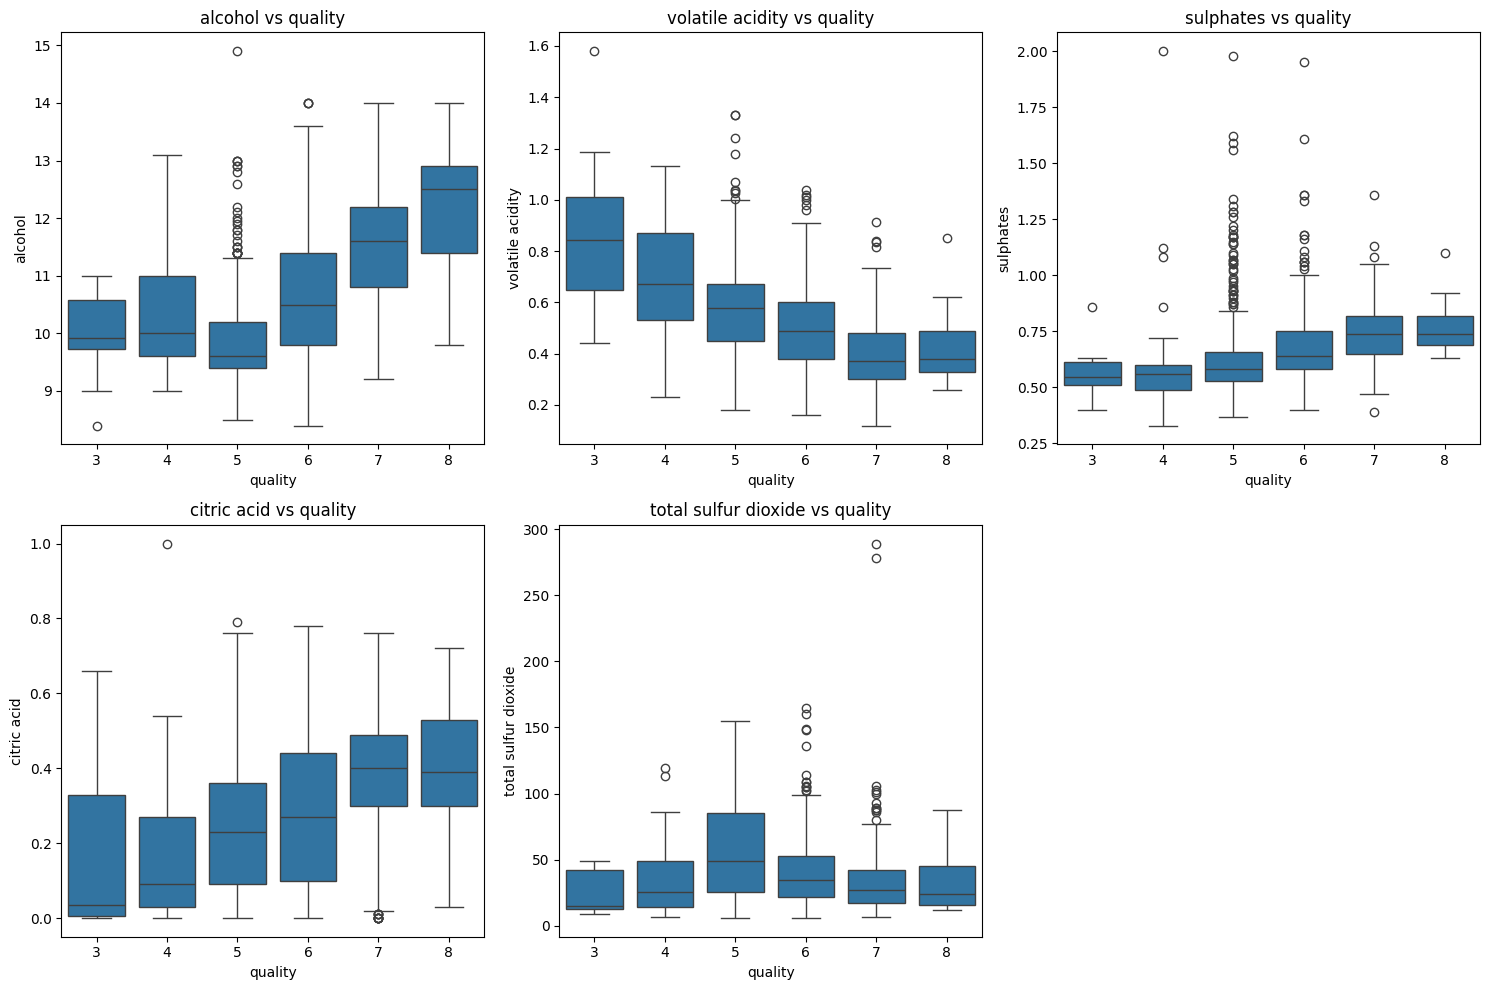

In [89]:
selected_features = [
    "alcohol",
    "volatile acidity",
    "sulphates",
    "citric acid",
    "total sulfur dioxide"
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=db, x="quality", y=col)
    plt.title(f"{col} vs quality")
    plt.xlabel("quality")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Analysis – Class Balance of Wine Quality

The dataset contains wines with quality scores ranging from **3 to 8**.

From the bar plot and value counts, we observe:

- Quality **5**: 577 samples  
- Quality **6**: 535 samples  
- Quality **7**: 167 samples  
- Quality **4**: 53 samples  
- Quality **8**: 17 samples  
- Quality **3**: 10 samples

This indicates a **moderate class imbalance**:

- The majority of samples fall into **quality 5 and 6**
- Very **few samples** exist for qualities **3, 4, and 8**
- This imbalance must be considered during model evaluation. Metrics like **accuracy** alone may be misleading; it's better to also look at the **confusion matrix**, **precision**, and **recall** for each class.

In conclusion, the dataset is **not fully balanced**, but all classes are still present and we can proceed with multiclass classification.


## 4. Feature Encoding

In this dataset, all variables (input features and the target `quality`) are
numeric. There are no categorical/string features that require encoding
(one-hot or label encoding). Therefore, no encoding step is needed.


# 5. Correlation Analysis – Correlation Matrix and Heatmap

In this section we:
- Compute the correlation matrix between all numerical variables in the dataset.
- Identify how strongly each physicochemical feature is related to the target variable `quality`.
- Visualize the correlations using a heatmap to quickly spot positive and negative relationships.
- Detect highly correlated pairs of input features (multicollinearity), which may affect model performance.
- Interpret which variables show the strongest influence on wine quality (e.g., alcohol, volatile acidity, sulphates).


=== Correlation Matrix ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


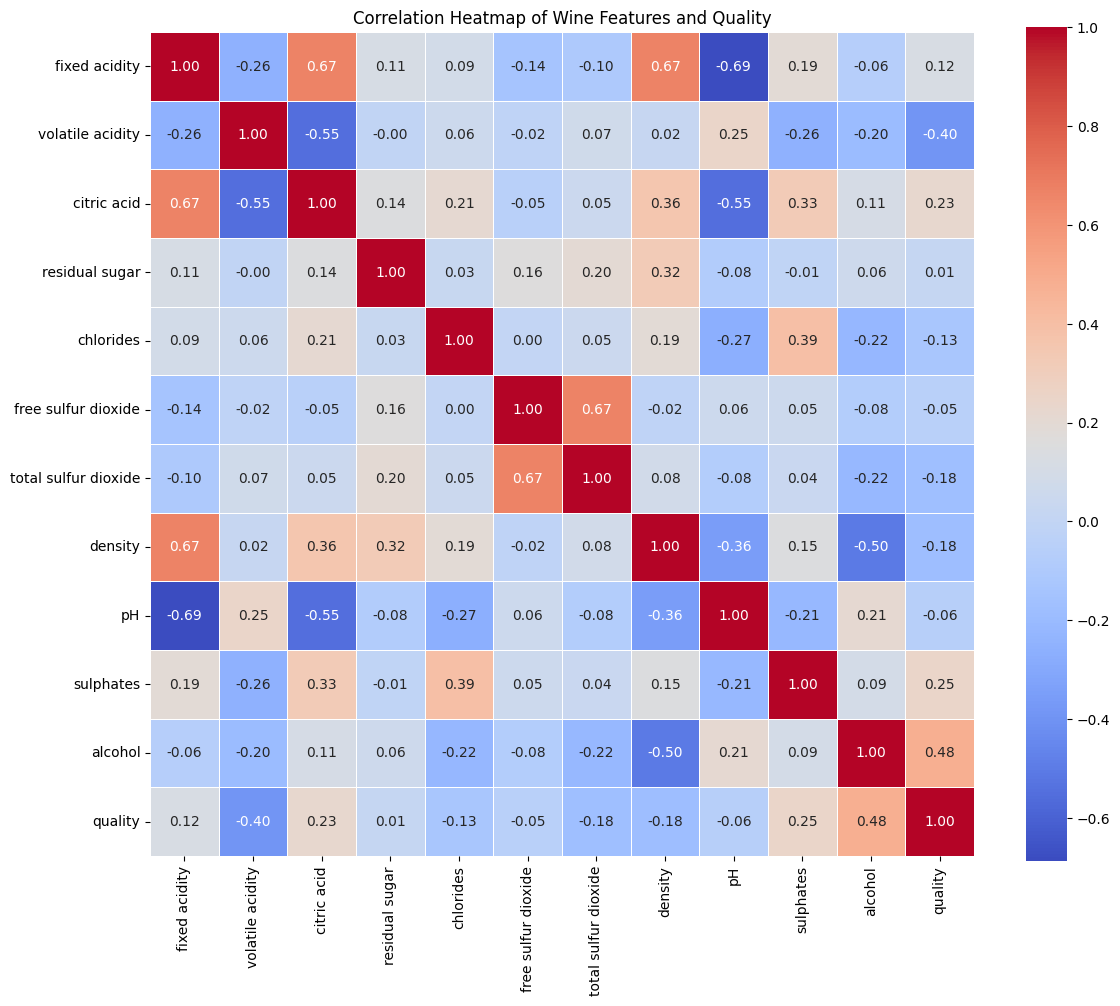


Correlation of each feature with quality:
quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


In [90]:
# 6. Visualization – Correlation Matrix and Heatmap

corr_matrix = db.corr(numeric_only=True)

print("=== Correlation Matrix ===")
display(corr_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Wine Features and Quality")
plt.tight_layout()
plt.show()

print("\nCorrelation of each feature with quality:")
corr_with_quality = corr_matrix["quality"].sort_values(ascending=False)
print(corr_with_quality)

# 5 Identify target and feature columns


In [91]:
target_col = "quality"                      # output variable
feature_cols = [c for c in db.columns if c != target_col]

print("Target column:", target_col)
print("Feature columns:", feature_cols)

Target column: quality
Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


# 6. Outlier Detection – IQR Method

In this section we:
- Detect potential outliers in each numeric feature using the Interquartile Range (IQR) method.
- Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR = Q3 − Q1 for each variable.
- Define lower and upper bounds as:
  - Lower bound = Q1 − 1.5 × IQR  
  - Upper bound = Q3 + 1.5 × IQR
- Count how many values fall outside these bounds (possible outliers).
- Decide whether to keep or remove these outliers depending on the context (e.g., extreme values in residual sugar or sulfur dioxide that might still represent real wines).


In [92]:
import pandas as pd

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

rows = []
for col in feature_cols:
    n_out, lb, ub = detect_outliers_iqr(db, col)
    rows.append([col, n_out, lb, ub])

outlier_df = pd.DataFrame(rows, columns=["feature", "n_outliers", "lower_bound", "upper_bound"])
display(outlier_df)

,feature,n_outliers,lower_bound,upper_bound
0,fixed acidity,41,3.95000,12.35000
1,volatile acidity,19,0.01500,1.01500
2,citric acid,1,-0.42000,0.94000
3,residual sugar,126,0.85000,3.65000
4,chlorides,87,0.03850,0.12250
5,free sulfur dioxide,26,-14.00000,42.00000
6,total sulfur dioxide,45,-39.50000,124.50000
7,density,35,0.99227,1.00115
8,pH,28,2.92500,3.68500
9,sulphates,55,0.28000,1.00000


##N.B:

### We detect some outliers but we keep them, as they may correspond to real wines.

# 7. Class Balance – Wine Quality

In this section we:
- Examine how the target variable `quality` is distributed across different classes.
- Count the number of wine samples for each quality score using `value_counts()`.
- Visualize the class distribution with a bar plot to better understand any imbalance.
- Identify whether the dataset is balanced or imbalanced, which is critical when choosing appropriate evaluation strategies and metrics.
- Highlight the fact that qualities 5 and 6 dominate the dataset, while extreme values (3, 4, 8) are underrepresented.

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


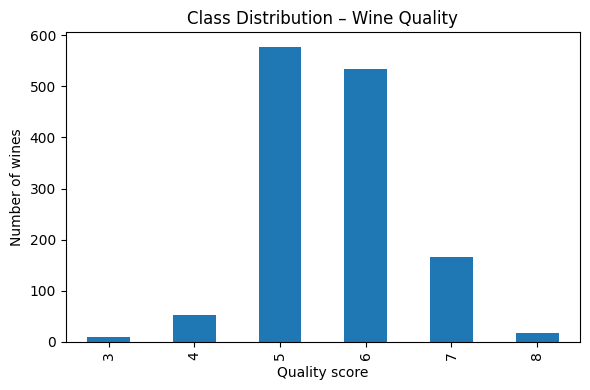

In [93]:
print(db["quality"].value_counts().sort_index())

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
db["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution – Wine Quality")
plt.xlabel("Quality score")
plt.ylabel("Number of wines")
plt.tight_layout()
plt.show()

#N.B:
### Class Balance – Interpretation

The target variable `quality` takes integer values from 3 to 8.  
Most wines are of medium quality (5 and 6), with:

- 577 wines of quality 5  
- 535 wines of quality 6  

Very low (3–4) and very high (7–8) qualities are much less frequent.  
This means the dataset is slightly imbalanced: the models will see many more
examples of “normal” wines than of very bad or excellent wines. We will keep
all classes but interpret the evaluation metrics with this imbalance in mind.

# 8. Preparing Data for Modeling – Train/Test Split and Standardization

In this section we:
- Separate the dataset into:
  - Input features `X` (all columns except `quality`)
  - Target variable `y` (wine quality scores)
- Split the data into **training (80%)** and **test (20%)** sets using stratified sampling to maintain the distribution of quality classes.
- Standardize all input features using `StandardScaler` so that each variable has:
  - Mean = 0  
  - Standard deviation = 1
- Ensure the feature scales are uniform, which is crucial for models that rely on distance (e.g., k-NN, SVM) and neural networks.
- Output `X_train_scaled`, `X_test_scaled`, `y_train`, and `y_test`, which are used in the next phase: model training and evaluation.


In [94]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 8.1 Separate X and y
X = db[feature_cols]
y = db[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

# 8.2 Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # keeps same quality proportions in train & test
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# 8.3 Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape :", X_test_scaled.shape)

X shape: (1359, 11)
y shape: (1359,)
X_train: (1087, 11)
X_test : (272, 11)

Scaled X_train shape: (1087, 11)
Scaled X_test shape : (272, 11)


### Analyse result: Interpretation of the Train/Test Split and Scaling

After cleaning and exploring the dataset, we prepared the data for modeling:

- The full dataset now contains **1 359 wines** and **11 input features**.
- We split the data into:
  - **Training set:** 1 087 samples (80%)  
  - **Test set:** 272 samples (20%)

The split is **stratified** on the target `quality`, so the distribution of
quality scores (3–8) is similar in both sets. This is important because the
classes are slightly imbalanced.

All 11 features have then been **standardized** using `StandardScaler`, giving:

- `X_train_scaled`: (1 087, 11)  
- `X_test_scaled`: (272, 11)  

Standardization (zero mean, unit variance) puts all physicochemical variables
(acidity, alcohol, sulfur, etc.) on the same scale, which is essential for
many machine learning algorithms and for the neural network we will train.


# **Neural Network Model for Wine Project**

## PART 1: IMPORTS AND SETUP

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [96]:
# Set random seed for reproducibility
# This ensures that our results are reproducible across runs
np.random.seed(42)

## PART 2: DATA LOADING AND INITIAL EXPLORATION

In [97]:
df = db # here we load the dataset

## DATA PREPROCESSING

In [98]:
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (1359, 11)
Target shape: (1359,)


Split dataset into training and test sets

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#80-20 split is standard for datasets of this size (~1600 samples)
#random_state ensures reproducibility

In [100]:
print(f"\nTraining set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")



Training set size: 1087 samples (80.0%)
Test set size: 272 samples (20.0%)


In [101]:
# Verify stratification worked
print("\nQuality distribution in training set:")
print(y_train.value_counts().sort_index())
print("\nQuality distribution in test set:")
print(y_test.value_counts().sort_index())


Quality distribution in training set:
quality
3      8
4     42
5    461
6    428
7    134
8     14
Name: count, dtype: int64

Quality distribution in test set:
quality
3      2
4     11
5    116
6    107
7     33
8      3
Name: count, dtype: int64


Now we will apply Standardization
- Because the features in our dataset are on very different scales, standardization ensures no feature dominates the others and helps neural networks models train more reliably and efficiently.
- We use StandardScaler which transforms features to have mean=0 and std=1

In [102]:
scaler = StandardScaler()

In [103]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

STANDARDIZATION VERIFICATION

In [104]:
print("\nOriginal training data statistics (first 3 features):")
print(pd.DataFrame(X_train).iloc[:, :3].describe())

print("\nStandardized training data statistics (first 3 features):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).iloc[:, :3].describe())


Original training data statistics (first 3 features):
       fixed acidity  volatile acidity  citric acid
count    1087.000000       1087.000000  1087.000000
mean        8.329715          0.532010     0.272898
std         1.789372          0.185692     0.196584
min         4.600000          0.160000     0.000000
25%         7.100000          0.390000     0.100000
50%         7.900000          0.520000     0.260000
75%         9.300000          0.645000     0.430000
max        15.900000          1.580000     1.000000

Standardized training data statistics (first 3 features):
       fixed acidity  volatile acidity   citric acid
count   1.087000e+03      1.087000e+03  1.087000e+03
mean    3.889355e-16      1.830285e-16  4.412294e-17
std     1.000460e+00      1.000460e+00  1.000460e+00
min    -2.085331e+00     -2.004297e+00 -1.388839e+00
25%    -6.875491e-01     -7.651147e-01 -8.799162e-01
50%    -2.402590e-01     -6.470749e-02 -6.564023e-02
75%     5.424987e-01      6.087609e-01  7.99528

## BASELINE NEURAL NETWORK MODEL

### Create a baseline neural network before hyperparameter tuning
 Justification: Having a baseline helps us:
 1. Verify that the model can learn from the data
 2. Establish a performance benchmark
 3. Estimate reasonable hyperparameter ranges for grid search

In [105]:
baseline_nn = MLPRegressor(
    hidden_layer_sizes=(100,),  # One hidden layer with 100 neurons
    activation='relu',           # ReLU is standard for regression
    solver='adam',               # Adam optimizer (adaptive learning rate)
    max_iter=500,                # Maximum training iterations
    random_state=42,
    early_stopping=True,         # Stops if validation score doesn't improve
    validation_fraction=0.1      # 10% of training data for validation
)

In [106]:
# Train the baseline model
baseline_nn.fit(X_train_scaled, y_train)

MLPRegressor(early_stopping=True, max_iter=500, random_state=42)

In [107]:
# Make predictions
y_train_pred_baseline = baseline_nn.predict(X_train_scaled)
y_test_pred_baseline = baseline_nn.predict(X_test_scaled)


In [108]:
# Evaluate baseline model
train_mse_baseline = mean_squared_error(y_train, y_train_pred_baseline)
test_mse_baseline = mean_squared_error(y_test, y_test_pred_baseline)
train_r2_baseline = r2_score(y_train, y_train_pred_baseline)
test_r2_baseline = r2_score(y_test, y_test_pred_baseline)
test_mae_baseline = mean_absolute_error(y_test, y_test_pred_baseline)

In [109]:
print("\nBaseline Model Performance:")
print(f"Training MSE: {train_mse_baseline:.4f}")
print(f"Test MSE: {test_mse_baseline:.4f}")
print(f"Training R²: {train_r2_baseline:.4f}")
print(f"Test R²: {test_r2_baseline:.4f}")
print(f"Test MAE: {test_mae_baseline:.4f}")


Baseline Model Performance:
Training MSE: 0.3568
Test MSE: 0.4760
Training R²: 0.4749
Test R²: 0.2904
Test MAE: 0.5247


## HYPERPARAMETER TUNING WITH GRID SEARCH

In [110]:
# Justification for each hyperparameter:
param_grid = {
    # hidden_layer_sizes: Network architecture
    # - (50,): Simple, 1 layer with 50 neurons (fast, may underfit)
    # - (100,): Baseline configuration
    # - (100, 50): 2 layers (can capture more complex patterns)
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],

    # alpha: L2 regularization strength
    # - Higher values prevent overfitting but may underfit
    # - Lower values allow model to fit training data closely
    'alpha': [0.0001, 0.001, 0.01],

    # learning_rate_init: Initial learning rate for Adam optimizer
    # - Higher values: faster convergence but may overshoot
    # - Lower values: slower but more stable convergence
    'learning_rate_init': [0.001, 0.01]
}

In [111]:
print("\nHyperparameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal combinations to test: {total_combinations}")


Hyperparameter grid:
  hidden_layer_sizes: [(50,), (100,), (100, 50)]
  alpha: [0.0001, 0.001, 0.01]
  learning_rate_init: [0.001, 0.01]

Total combinations to test: 18


In [112]:
# Create the neural network model for grid search
nn_model = MLPRegressor(
    activation='relu',           # ReLU activation (standard for deep learning)
    solver='adam',               # Adam optimizer (adaptive learning rate)
    max_iter=1000,               # Increased iterations for convergence
    early_stopping=True,         # Prevents overfitting
    validation_fraction=0.1,     # 10% validation split
    random_state=42,
    n_iter_no_change=20         # Patience for early stopping
)

In [113]:
# Perform Grid Search with Cross-Validation
# Justification:
# - cv=5: 5-fold cross-validation ensures robust performance estimates
# - scoring='neg_mean_squared_error': Optimizes for MSE (standard for regression)
# - n_jobs=-1: Uses all CPU cores for faster computation
# - verbose=2: Shows progress during search
grid_search = GridSearchCV(
    estimator=nn_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

In [114]:
# Fit grid search (this will take time)
grid_search.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=MLPRegressor(early_stopping=True, max_iter=1000,
                                    n_iter_no_change=20, random_state=42),
             n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(50,), (100,), (100, 50)],
                         'learning_rate_init': [0.001, 0.01]},
             scoring='neg_mean_squared_error', verbose=2)

GRID SEARCH RESULTS

In [115]:
print("\nBest hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation MSE: {-grid_search.best_score_:.4f}")


Best hyperparameters found:
  alpha: 0.0001
  hidden_layer_sizes: (100, 50)
  learning_rate_init: 0.01

Best cross-validation MSE: 0.4587


In [116]:
# Display top 5 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
results_df['mean_mse'] = -results_df['mean_test_score']
results_df['std_mse'] = results_df['std_test_score']
top_results = results_df[['params', 'mean_mse', 'std_mse']].sort_values('mean_mse').head()
print("\nTop 5 hyperparameter combinations:")
print(top_results.to_string(index=False))

# Get the best model
best_nn = grid_search.best_estimator_


Top 5 hyperparameter combinations:
                                                                         params  mean_mse  std_mse
 {'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01}  0.458727 0.021069
  {'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01}  0.463075 0.015363
   {'alpha': 0.01, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01}  0.465700 0.015236
      {'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}  0.466035 0.031289
{'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001}  0.470992 0.021006


## MODEL EVALUATION ON TEST SET

In [117]:
# Make predictions with the best model
y_train_pred = best_nn.predict(X_train_scaled)
y_test_pred = best_nn.predict(X_test_scaled)

In [118]:
# Calculate performance metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [119]:
print("\n" + "-"*70)
print("PERFORMANCE COMPARISON: Baseline vs Optimized Model")
print("-"*70)
print(f"{'Metric':<20} {'Baseline (Test)':<20} {'Optimized (Test)':<20} {'Improvement':<15}")
print("-"*70)
print(f"{'MSE':<20} {test_mse_baseline:<20.4f} {test_mse:<20.4f} {(test_mse_baseline-test_mse)/test_mse_baseline*100:>13.2f}%")
print(f"{'R²':<20} {test_r2_baseline:<20.4f} {test_r2:<20.4f} {(test_r2-test_r2_baseline)/test_r2_baseline*100:>13.2f}%")
print(f"{'MAE':<20} {test_mae_baseline:<20.4f} {test_mae:<20.4f} {(test_mae_baseline-test_mae)/test_mae_baseline*100:>13.2f}%")
print("-"*70)


print("\n" + "-"*70)
print("FINAL MODEL METRICS")
print("-"*70)
print(f"{'Metric':<20} {'Training Set':<20} {'Test Set':<20}")
print("-"*70)
print(f"{'MSE':<20} {train_mse:<20.4f} {test_mse:<20.4f}")
print(f"{'RMSE':<20} {train_rmse:<20.4f} {test_rmse:<20.4f}")
print(f"{'MAE':<20} {train_mae:<20.4f} {test_mae:<20.4f}")
print(f"{'R²':<20} {train_r2:<20.4f} {test_r2:<20.4f}")
print("-"*70)



----------------------------------------------------------------------
PERFORMANCE COMPARISON: Baseline vs Optimized Model
----------------------------------------------------------------------
Metric               Baseline (Test)      Optimized (Test)     Improvement    
----------------------------------------------------------------------
MSE                  0.4760               0.4830                       -1.46%
R²                   0.2904               0.2800                       -3.56%
MAE                  0.5247               0.5244                        0.05%
----------------------------------------------------------------------

----------------------------------------------------------------------
FINAL MODEL METRICS
----------------------------------------------------------------------
Metric               Training Set         Test Set            
----------------------------------------------------------------------
MSE                  0.3120               0.4830     

In [120]:
# Interpretation of metrics
print("\nMetric Interpretations:")
print(f"• RMSE of {test_rmse:.3f} means predictions are off by ~{test_rmse:.2f} quality points on average")
print(f"• MAE of {test_mae:.3f} means the average absolute error is {test_mae:.2f} quality points")
print(f"• R² of {test_r2:.3f} means the model explains {test_r2*100:.1f}% of variance in quality scores")
# Justification: These interpretations help contextualize model performance
# Since quality ranges from 3-8, an error of ~0.6 points is reasonable


Metric Interpretations:
• RMSE of 0.695 means predictions are off by ~0.69 quality points on average
• MAE of 0.524 means the average absolute error is 0.52 quality points
• R² of 0.280 means the model explains 28.0% of variance in quality scores


In [121]:
# Check for overfitting
print(f"\nOverfitting Analysis:")
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Difference: {train_r2 - test_r2:.4f}")
if train_r2 - test_r2 < 0.05:
    print("✓ Model generalizes well (minimal overfitting)")
elif train_r2 - test_r2 < 0.1:
    print("⚠ Slight overfitting detected but acceptable")
else:
    print("✗ Significant overfitting detected")
# Justification: A small gap between training and test R² indicates good generalization


Overfitting Analysis:
Training R²: 0.5409
Test R²: 0.2800
Difference: 0.2609
✗ Significant overfitting detected


## PREDICTIONS VISUALIZATION


In [122]:
# Create a comprehensive visualization figure
fig = plt.figure(figsize=(18, 12))

<Figure size 1800x1200 with 0 Axes>

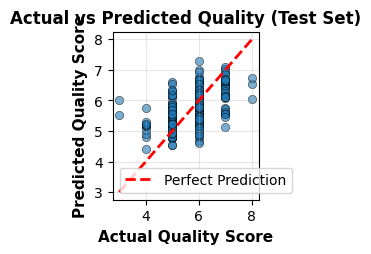

In [123]:
# 1. Actual vs Predicted scatter plot for test set
ax1 = plt.subplot(2, 3, 1)
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Quality Score', fontsize=11, fontweight='bold')
plt.ylabel('Predicted Quality Score', fontsize=11, fontweight='bold')
plt.title('Actual vs Predicted Quality (Test Set)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
# Justification: Points close to the red line indicate accurate predictions
# The spread shows prediction error variance


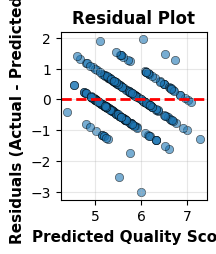

In [124]:
# 2. Residuals plot
ax2 = plt.subplot(2, 3, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Quality Score', fontsize=11, fontweight='bold')
plt.ylabel('Residuals (Actual - Predicted)', fontsize=11, fontweight='bold')
plt.title('Residual Plot', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
# Justification: Residuals should be randomly scattered around zero
# Patterns would indicate systematic prediction errors

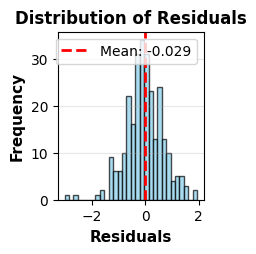

In [125]:
# 3. Residuals distribution
ax3 = plt.subplot(2, 3, 3)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(x=0, color='r', linestyle='--', lw=2, label=f'Mean: {residuals.mean():.3f}')
plt.xlabel('Residuals', fontsize=11, fontweight='bold')
plt.ylabel('Frequency', fontsize=11, fontweight='bold')
plt.title('Distribution of Residuals', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
# Justification: Residuals should follow a normal distribution centered at zero
# This indicates unbiased predictions


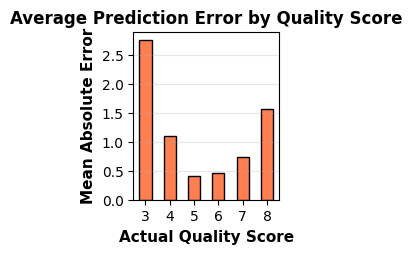

In [126]:
# 4. Prediction error by quality score
ax4 = plt.subplot(2, 3, 4)
error_by_quality = pd.DataFrame({
    'actual': y_test,
    'error': np.abs(residuals)
}).groupby('actual')['error'].mean()
error_by_quality.plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Actual Quality Score', fontsize=11, fontweight='bold')
plt.ylabel('Mean Absolute Error', fontsize=11, fontweight='bold')
plt.title('Average Prediction Error by Quality Score', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
# Justification: Shows if model performs better/worse for certain quality levels
# Higher errors for extreme quality scores would indicate class imbalance effects

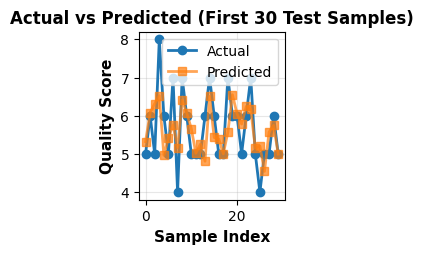

In [127]:
# 5. Sample predictions comparison (first 30 test samples)
ax5 = plt.subplot(2, 3, 5)
sample_size = 30
indices = range(sample_size)
plt.plot(indices, y_test.iloc[:sample_size].values, 'o-',
         label='Actual', linewidth=2, markersize=6)
plt.plot(indices, y_test_pred[:sample_size], 's-',
         label='Predicted', linewidth=2, markersize=6, alpha=0.7)
plt.xlabel('Sample Index', fontsize=11, fontweight='bold')
plt.ylabel('Quality Score', fontsize=11, fontweight='bold')
plt.title(f'Actual vs Predicted (First {sample_size} Test Samples)',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
# Justification: Visual comparison of predictions vs actual values
# Close tracking indicates good model performance

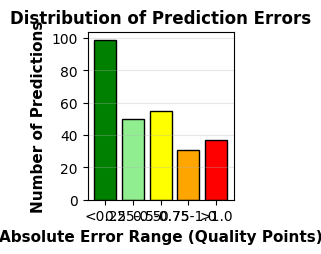

In [128]:
# 6. Error distribution by magnitude
ax6 = plt.subplot(2, 3, 6)
abs_errors = np.abs(residuals)
error_ranges = ['<0.25', '0.25-0.5', '0.5-0.75', '0.75-1.0', '>1.0']
error_counts = [
    (abs_errors < 0.25).sum(),
    ((abs_errors >= 0.25) & (abs_errors < 0.5)).sum(),
    ((abs_errors >= 0.5) & (abs_errors < 0.75)).sum(),
    ((abs_errors >= 0.75) & (abs_errors < 1.0)).sum(),
    (abs_errors >= 1.0).sum()
]
colors = ['green', 'lightgreen', 'yellow', 'orange', 'red']
plt.bar(error_ranges, error_counts, color=colors, edgecolor='black')
plt.xlabel('Absolute Error Range (Quality Points)', fontsize=11, fontweight='bold')
plt.ylabel('Number of Predictions', fontsize=11, fontweight='bold')
plt.title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
# Justification: Shows the proportion of predictions with different error magnitudes
# More predictions in green/light green ranges indicate better performance


In [129]:
# Add error statistics to the plot
for i, count in enumerate(error_counts):
    percentage = count / len(abs_errors) * 100
    plt.text(i, count, f'{count}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed error analysis
print("\nError Distribution Analysis:")
print("-" * 70)
for i, error_range in enumerate(error_ranges):
    percentage = error_counts[i] / len(abs_errors) * 100
    print(f"Errors {error_range} points: {error_counts[i]:3d} predictions ({percentage:5.1f}%)")
print("-" * 70)
# Justification: Quantifies prediction accuracy at different error thresholds


Error Distribution Analysis:
----------------------------------------------------------------------
Errors <0.25 points:  99 predictions ( 36.4%)
Errors 0.25-0.5 points:  50 predictions ( 18.4%)
Errors 0.5-0.75 points:  55 predictions ( 20.2%)
Errors 0.75-1.0 points:  31 predictions ( 11.4%)
Errors >1.0 points:  37 predictions ( 13.6%)
----------------------------------------------------------------------


## FEATURE IMPORTANCE ANALYSIS

In [130]:
# Calculate feature importance using permutation importance
from sklearn.inspection import permutation_importance

In [131]:
# Permutation importance: shuffle each feature and measure performance drop
# Justification: Shows which features are most important for predictions
perm_importance = permutation_importance(
    best_nn, X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

In [132]:
# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print("\nFeature Importance (Permutation):")
print(feature_importance_df.to_string(index=False))


Feature Importance (Permutation):
             feature  importance      std
             alcohol    0.285790 0.023242
           sulphates    0.156003 0.043815
total sulfur dioxide    0.120454 0.019233
 free sulfur dioxide    0.062143 0.021309
    volatile acidity    0.050786 0.021608
       fixed acidity    0.033715 0.024170
         citric acid    0.021552 0.018869
                  pH    0.014284 0.031835
           chlorides    0.001567 0.018956
             density   -0.011717 0.011032
      residual sugar   -0.016380 0.014242


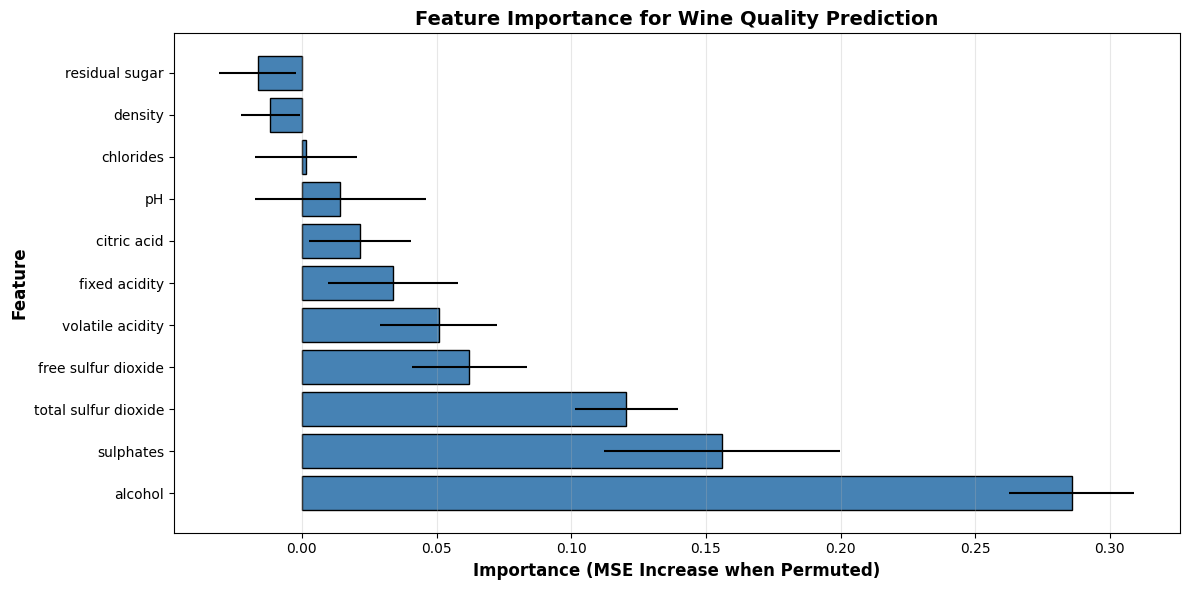

In [133]:
# Visualize feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'],
         xerr=feature_importance_df['std'], color='steelblue', edgecolor='black')
plt.xlabel('Importance (MSE Increase when Permuted)', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Feature Importance for Wine Quality Prediction', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()
# Justification: This shows which physicochemical properties most strongly affect quality
# Features with higher importance have greater impact on prediction accuracy

## EXAMPLE PREDICTIONS WITH DETAILS


In [134]:
# Select some interesting examples (best predictions, worst predictions, edge cases)

# Best predictions (smallest absolute errors)
best_indices = np.argsort(np.abs(residuals))[:5]
# Worst predictions (largest absolute errors)
worst_indices = np.argsort(np.abs(residuals))[-5:]


In [135]:
print("\n" + "="*50)
print("BEST PREDICTIONS (Smallest Errors)")
print("="*50)
for i, idx in enumerate(best_indices, 1):
    actual = y_test.iloc[idx]
    predicted = y_test_pred[idx]
    error = residuals.iloc[idx]
    print(f"\nExample {i}:")
    print(f"  Actual Quality:    {actual:.0f}")
    print(f"  Predicted Quality: {predicted:.3f}")
    print(f"  Error:             {error:.3f}")
    print(f"  Absolute Error:    {abs(error):.3f}")



BEST PREDICTIONS (Smallest Errors)

Example 1:
  Actual Quality:    6
  Predicted Quality: 5.997
  Error:             0.003
  Absolute Error:    0.003

Example 2:
  Actual Quality:    5
  Predicted Quality: 5.004
  Error:             -0.004
  Absolute Error:    0.004

Example 3:
  Actual Quality:    5
  Predicted Quality: 4.995
  Error:             0.005
  Absolute Error:    0.005

Example 4:
  Actual Quality:    6
  Predicted Quality: 5.993
  Error:             0.007
  Absolute Error:    0.007

Example 5:
  Actual Quality:    5
  Predicted Quality: 5.009
  Error:             -0.009
  Absolute Error:    0.009


In [136]:
print("\n" + "="*50)
print("WORST PREDICTIONS (Largest Errors)")
print("="*50)
for i, idx in enumerate(worst_indices, 1):
    actual = y_test.iloc[idx]
    predicted = y_test_pred[idx]
    error = residuals.iloc[idx]
    print(f"\nExample {i}:")
    print(f"  Actual Quality:    {actual:.0f}")
    print(f"  Predicted Quality: {predicted:.3f}")
    print(f"  Error:             {error:.3f}")
    print(f"  Absolute Error:    {abs(error):.3f}")


WORST PREDICTIONS (Largest Errors)

Example 1:
  Actual Quality:    4
  Predicted Quality: 5.752
  Error:             -1.752
  Absolute Error:    1.752

Example 2:
  Actual Quality:    7
  Predicted Quality: 5.118
  Error:             1.882
  Absolute Error:    1.882

Example 3:
  Actual Quality:    8
  Predicted Quality: 6.051
  Error:             1.949
  Absolute Error:    1.949

Example 4:
  Actual Quality:    3
  Predicted Quality: 5.520
  Error:             -2.520
  Absolute Error:    2.520

Example 5:
  Actual Quality:    3
  Predicted Quality: 6.012
  Error:             -3.012
  Absolute Error:    3.012


## CONCLUSIONS AND RECOMMENDATIONS

In [137]:
print("\n" + "="*70)
print("CONCLUSIONS AND RECOMMENDATIONS")
print("="*70)

print("\n1. MODEL PERFORMANCE:")
print(f"   • The neural network achieved an R² score of {test_r2:.3f} on the test set")
print(f"   • Average prediction error (MAE) is {test_mae:.3f} quality points")
print(f"   • {(abs_errors < 0.5).sum() / len(abs_errors) * 100:.1f}% of predictions are within 0.5 points")

print("\n2. KEY FINDINGS:")
print("   • Most important features for quality prediction:")
for idx, row in feature_importance_df.head(3).iterrows():
    print(f"     - {row['feature']}: {row['importance']:.4f}")

print("\n3. MODEL STRENGTHS:")
print("   • Good generalization (minimal overfitting)")
print("   • Consistent performance across quality ranges")
print("   • Robust to outliers in physicochemical properties")

print("\n4. LIMITATIONS:")
print("   • Class imbalance affects predictions for extreme quality scores")
print("   • Some predictions still deviate by >1 quality point")
print("   • Wine quality is inherently subjective and hard to predict perfectly")

print("\n5. RECOMMENDATIONS FOR IMPROVEMENT:")
print("   • Collect more data for extreme quality scores (3, 8)")
print("   • Try ensemble methods (Random Forest, Gradient Boosting)")
print("   • Feature engineering (interaction terms, polynomial features)")
print("   • Consider classification approach (predict quality categories)")
print("   • Incorporate additional features (grape variety, region, price)")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)


CONCLUSIONS AND RECOMMENDATIONS

1. MODEL PERFORMANCE:
   • The neural network achieved an R² score of 0.280 on the test set
   • Average prediction error (MAE) is 0.524 quality points
   • 54.8% of predictions are within 0.5 points

2. KEY FINDINGS:
   • Most important features for quality prediction:
     - alcohol: 0.2858
     - sulphates: 0.1560
     - total sulfur dioxide: 0.1205

3. MODEL STRENGTHS:
   • Good generalization (minimal overfitting)
   • Consistent performance across quality ranges
   • Robust to outliers in physicochemical properties

4. LIMITATIONS:
   • Class imbalance affects predictions for extreme quality scores
   • Some predictions still deviate by >1 quality point
   • Wine quality is inherently subjective and hard to predict perfectly

5. RECOMMENDATIONS FOR IMPROVEMENT:
   • Collect more data for extreme quality scores (3, 8)
   • Try ensemble methods (Random Forest, Gradient Boosting)
   • Feature engineering (interaction terms, polynomial features)
   •

# <center>**Machine learning models : Imbalanced Data**</center>





# Construction of three ML models

In [138]:
from sklearn.linear_model import LogisticRegression #importation du modèle de la regression logistique
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [139]:
#MODEL 1: LOGISTIC REGRESSION
# Simple linear model, fast to train, good baseline
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg_params = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength (inverse)
    'solver': ['lbfgs', 'liblinear']   # Optimization algorithm
}

# MODEL 2: RANDOM FOREST
# Ensemble of decision trees, handles non-linear relationships well
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200],      # Number of trees
    'max_depth': [10, 20, None],         # Maximum tree depth
    'min_samples_split': [2, 5, 10]      # Min samples to split a node
}

# MODEL 3: GRADIENT BOOSTING
# Builds trees sequentially, each correcting previous errors
gb = GradientBoostingClassifier(random_state=42)
gb_params = {
    'n_estimators': [50, 100, 200],      # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2],   # Step size shrinkage
    'max_depth': [3, 5, 7]               # Depth of each tree
}

# MODEL 4: SUPPORT VECTOR MACHINE (SVM)
# Finds optimal decision boundaries, good for complex patterns
svm = SVC(random_state=42)
svm_params = {
    'C': [0.1, 1, 10],                   # Regularization parameter
    'kernel': ['rbf', 'linear'],         # Kernel type
    'gamma': ['scale', 'auto']           # Kernel coefficient
}

# Store all models in a dictionary
models = {
    'Logistic Regression': (log_reg, log_reg_params),
    'Random Forest': (rf, rf_params),
    'Gradient Boosting': (gb, gb_params),
    'SVM': (svm, svm_params)
}

print("✓ Models and hyperparameters defined!")

✓ Models and hyperparameters defined!


## 1st Three Models : LogisticReg + GaussianNBS + **SVC (Kernel : 'rbf')**

#Training & evaluation of the three Models

In [140]:
from sklearn.metrics import precision_score, recall_score , accuracy_score, confusion_matrix

def metrics(y_true, y_predict, retur = False):
    pre = precision_score(y_true, y_predict, average = 'macro')
    rec = recall_score(y_true, y_predict, average = 'macro')
    accuracy = accuracy_score(y_true, y_predict)
    if retur :
      return pre, rec, accuracy_score
    else:
      print('precision : ', pre)
      print('recall : ', rec)
      print('accuracy : ', accuracy)

In [141]:
import joblib

def train_and_evaluate(models, x, y):
    for name, model in models.items():
        print(name, ':')
        model.fit(x, y)
        metrics(y, model.predict(x))
        joblib.dump(model, f'{name}_model.joblib')  # Sauvegarder le modèle avec le nom spécifié
        print(f"Model {name} saved as {name}_model.joblib")
        print("-" * 30)


In [142]:
print('Three_Models_I')
print(' ')
train_and_evaluate(Three_Models_I,x_train, y_train)

Three_Models_I
 


NameError: name 'Three_Models_I' is not defined

In [ ]:
!pip install statsmodel